# **1. Perkenalan Dataset**


Sumber dataset (Kaggle): https://www.kaggle.com/datasets/gpreda/covid-world-vaccination-progress


Dataset ini berisi informasi vaksinasi yang berasal dari repositori GitHub [Our World in Data](https://ourworldindata.org/) untuk mendapatkan wawasan lebih lanjut tentang dinamika pandemi, seperti yang tercermin dalam saling ketergantungan jumlah pengujian yang dilakukan, hasil pengurutan, dan kampanye vaksinasi.


Variabel target adalah `daily_vaccinations`, yaitu jumlah vaksinasi harian pada suatu negara di tanggal tertentu. Variabel ini cocok digunakan jika tujuan analisis atau model adalah memprediksi perkembangan jumlah vaksinasi harian berdasarkan negara, tanggal, total vaksinasi, jumlah orang yang sudah divaksin, jumlah orang yang sudah divaksin lengkap, dan rasio vaksinasi terhadap populasi.


Penggunaan umum:

Dataset ini umum digunakan untuk analisis eksploratif data atau Exploratory Data Analysis (EDA), visualisasi tren vaksinasi COVID-19, perbandingan progres vaksinasi antarnegara, analisis jenis vaksin yang digunakan di berbagai negara, serta pembuatan model prediksi jumlah vaksinasi harian. Dataset ini juga dapat membantu melihat seberapa cepat program vaksinasi berjalan dari waktu ke waktu dan bagaimana cakupan vaksinasi berbeda antarwilayah. Dataset Kaggle ini memang berisi data vaksinasi harian dan total vaksinasi COVID-19 dunia dari Our World in Data.


Kolom:
*   `country`: Negara tempat informasi vaksinasi disediakan (string)
*   `iso_code`: Kode ISO untuk negara tersebut
*   `date`: Tanggal untuk entri data. (Untuk beberapa tanggal, kami hanya memiliki data vaksinasi harian, untuk tanggal lainnya, hanya total (kumulatif)).
*   `total_vaccinations`: Angka absolut dari total imunisasi di negara tersebut.
*   `people_vaccinated`: Tergantung pada skema imunisasi, seseorang akan menerima satu atau lebih (biasanya 2) vaksin. (Pada saat tertentu, jumlah vaksinasi mungkin lebih besar daripada jumlah orang).
*   `people_fully_vaccinated`: Jumlah orang yang menerima seluruh rangkaian imunisasi sesuai dengan skema imunisasi (biasanya 2). (Pada suatu waktu tertentu, mungkin ada sejumlah orang yang menerima satu vaksin dan sejumlah orang lain (lebih kecil) yang menerima semua vaksin dalam skema tersebut).
*   `daily_vaccinations_raw`: Jumlah vaksinasi harian pada suatu negara di tanggal tertentu.
*   `daily_vaccinations`: Jumlah vaksinasi harian pada suatu negara di tanggal tertentu.
*   `total_vaccinations_per_hundred`: Rasio (dalam persen) antara jumlah vaksinasi dan total populasi hingga saat ini di negara tersebut
*   `people_vaccinated_per_hundred`: Rasio (dalam persen) antara populasi yang diimunisasi dan total populasi hingga saat ini di negara tersebut
*   `people_fully_vaccinated_per_hundred`: Rasio (dalam persen) antara populasi yang telah diimunisasi lengkap dan total populasi hingga saat ini di negara tersebut
*   `daily_vaccinations_per_million`: Rasio (dalam ppm) antara jumlah vaksinasi dan total populasi pada tanggal saat ini di negara tersebut.
*   `vaccines`: Jumlah total vaksin yang digunakan di negara tersebut (hingga saat ini)
*   `source_name`: Sumber informasi (otoritas nasional, organisasi internasional, organisasi lokal, dll.)
*   `source_website`: Situs web sumber informasi

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Mendownload dataset dari Kaggle
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!kaggle datasets download -d gpreda/covid-world-vaccination-progress
# Ekstrak file zip
!unzip covid-world-vaccination-progress.zip
# Load dataset
data = pd.read_csv('country_vaccinations.csv')

Dataset URL: https://www.kaggle.com/datasets/gpreda/covid-world-vaccination-progress
License(s): CC0-1.0
100% 1.94M/1.94M [00:01<00:00, 1.67MB/s]

Archive:  covid-world-vaccination-progress.zip
  inflating: country_vaccinations.csv  
  inflating: country_vaccinations_by_manufacturer.csv  


In [3]:
# Menampilkan 10 baris pertama dataset
data.head(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
5,Afghanistan,AFG,2021-02-27,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
6,Afghanistan,AFG,2021-02-28,8200.0,8200.0,NaN,NaN,1367.0,0.02,0.02,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
7,Afghanistan,AFG,2021-03-01,NaN,NaN,NaN,NaN,1580.0,NaN,NaN,NaN,40.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
8,Afghanistan,AFG,2021-03-02,NaN,NaN,NaN,NaN,1794.0,NaN,NaN,NaN,45.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
9,Afghanistan,AFG,2021-03-03,NaN,NaN,NaN,NaN,2008.0,NaN,NaN,NaN,50.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [4]:
# Menampilkan 10 baris terakhir dataset
data.tail(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
86502,Zimbabwe,ZWE,2022-03-20,8210637.0,4418956.0,3444793.0,2915.0,30641.0,54.40,29.28,22.83,2030.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86503,Zimbabwe,ZWE,2022-03-21,8230061.0,4432618.0,3446894.0,19424.0,9630.0,54.53,29.37,22.84,638.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86504,Zimbabwe,ZWE,2022-03-22,8313471.0,4503937.0,3450864.0,83410.0,19990.0,55.08,29.84,22.87,1325.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86505,Zimbabwe,ZWE,2022-03-23,8414477.0,4589712.0,3455926.0,101006.0,32456.0,55.75,30.41,22.90,2151.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86506,Zimbabwe,ZWE,2022-03-24,8552429.0,4704720.0,3461926.0,137952.0,51151.0,56.67,31.17,22.94,3389.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86507,Zimbabwe,ZWE,2022-03-25,8691642.0,4814582.0,3473523.0,139213.0,69579.0,57.59,31.90,23.02,4610.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86508,Zimbabwe,ZWE,2022-03-26,8791728.0,4886242.0,3487962.0,100086.0,83429.0,58.25,32.38,23.11,5528.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86509,Zimbabwe,ZWE,2022-03-27,8845039.0,4918147.0,3493763.0,53311.0,90629.0,58.61,32.59,23.15,6005.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86510,Zimbabwe,ZWE,2022-03-28,8934360.0,4975433.0,3501493.0,89321.0,100614.0,59.20,32.97,23.20,6667.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86511,Zimbabwe,ZWE,2022-03-29,9039729.0,5053114.0,3510256.0,105369.0,103751.0,59.90,33.48,23.26,6874.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Mengetahui kolom mana yang masih memiliki nilai kosong
data.isnull().sum()

,0
country,0
iso_code,0
date,0
total_vaccinations,42905
people_vaccinated,45218
people_fully_vaccinated,47710
daily_vaccinations_raw,51150
daily_vaccinations,299
total_vaccinations_per_hundred,42905
people_vaccinated_per_hundred,45218


In [6]:
# Menampilkan banyak data duplikat
print(data.duplicated().sum())

0


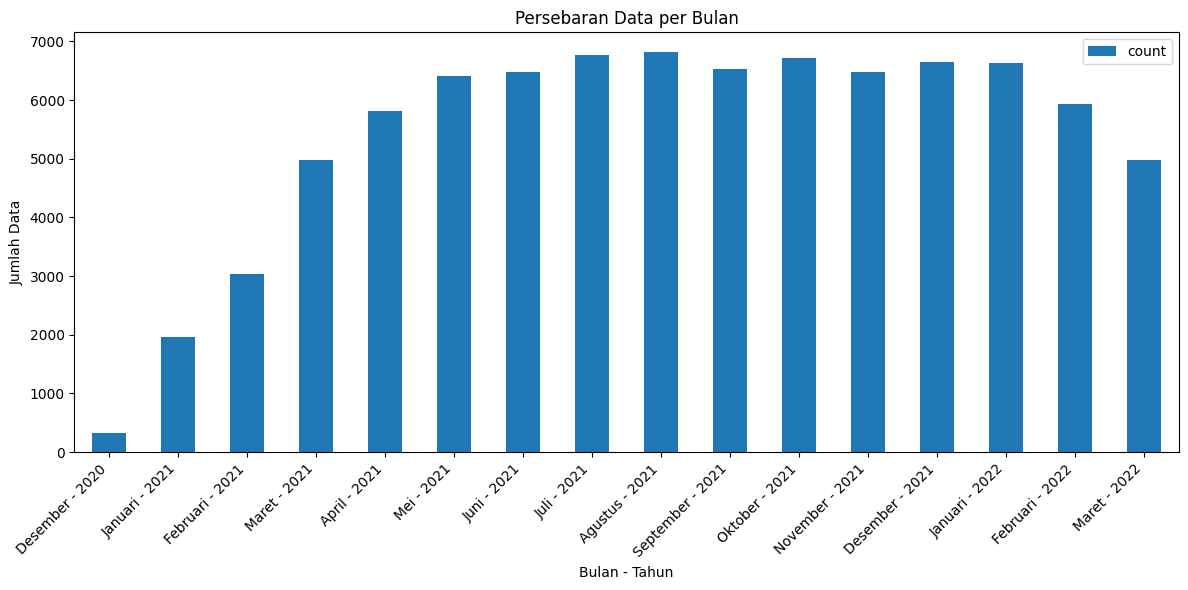

In [7]:
# Menampilkan data persebaran setiap bulan melalui diagram batang
data['date'] = pd.to_datetime(data['date'])

# Buat periode agar urutan bulan-tahun tetap benar
data['period'] = data['date'].dt.to_period('M')

# Hitung jumlah data per bulan-tahun
result = data.groupby('period').size().reset_index(name='count')

# Nama bulan bahasa Indonesia
nama_bulan = {
    1: 'Januari',
    2: 'Februari',
    3: 'Maret',
    4: 'April',
    5: 'Mei',
    6: 'Juni',
    7: 'Juli',
    8: 'Agustus',
    9: 'September',
    10: 'Oktober',
    11: 'November',
    12: 'Desember'
}

result['monthly'] = (
    result['period'].dt.month.map(nama_bulan)
    + ' - '
    + result['period'].dt.year.astype(str)
)

ax = result.plot(
    kind='bar',
    x='monthly',
    y='count',
    figsize=(12, 6)
)

plt.xlabel('Bulan - Tahun')
plt.ylabel('Jumlah Data')
plt.title('Persebaran Data per Bulan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# Membuat salinan DataFrame
df = data.copy()

In [9]:
# Mengurutkan data berdasarkan negara dan tanggal
df = df.sort_values(['country', 'date'])

# Mengisi nilai kosong berdasarkan data sebelumnya di negara yang sama
numeric_cols = [
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'daily_vaccinations_raw',
    'daily_vaccinations',
    'total_vaccinations_per_hundred',
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'daily_vaccinations_per_million'
]

df[numeric_cols] = df.groupby('country')[numeric_cols].ffill()

# Jika masih ada nilai kosong, isi dengan 0
df[numeric_cols] = df[numeric_cols].fillna(0)

In [10]:
# Menghapus kolom yang kurang diperlukan
df = df.drop(columns=['source_website', 'source_name'])

In [11]:
# Karena nilai seperti total_vaccinations bisa sangat besar, sedangkan per_hundred kecil, sebaiknya distandarisasi.
df[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])

In [12]:
# Deteksi Outlier
df[numeric_cols].describe()

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
count,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04
mean,-1.971175e-17,2.628233e-18,-1.445528e-17,1.708351e-17,1.314116e-17,-1.300975e-16,1.498093e-16,-4.205172e-17,2.989615e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-1.603667e-01,-1.712018e-01,-1.517891e-01,-1.693298e-01,-1.706284e-01,-1.028876e+00,-1.180418e+00,-9.788351e-01,-8.256556e-01
25%,-1.596360e-01,-1.702530e-01,-1.514469e-01,-1.693298e-01,-1.694797e-01,-9.226397e-01,-1.012195e+00,-9.299052e-01,-6.657056e-01
50%,-1.536793e-01,-1.624437e-01,-1.465670e-01,-1.645623e-01,-1.611570e-01,-3.028524e-01,-1.754818e-01,-3.842313e-01,-3.076618e-01
75%,-1.091770e-01,-1.140445e-01,-1.040319e-01,-1.213722e-01,-1.136307e-01,7.856078e-01,9.435210e-01,9.049633e-01,3.613818e-01
max,2.004804e+01,1.624207e+01,1.868032e+01,3.057190e+01,2.906789e+01,4.265607e+00,3.042413e+00,3.359964e+00,2.905295e+01


In [13]:
# Menyimpan dataset hasil preprocessing secara utuh
df.to_csv('country_vaccinations_preprocessed.csv', index=False)

# Memisahkan dataset menjadi data latih dan data uji (train/test split)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Menyimpan data latih dan data uji ke dalam file CSV
train_df.to_csv('country_vaccinations_train.csv', index=False)
test_df.to_csv('country_vaccinations_test.csv', index=False)

print('Dataset hasil preprocessing dan split train/test berhasil disimpan!')

Dataset hasil preprocessing dan split train/test berhasil disimpan!
